In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [8]:
from src.data_loader import load_data
from src.preprocess import prepare_features, split_data
from src.models import train_random_forest, train_adaboost, train_xgboost
from src.metrics import evaluate_model, build_results_dataframe
from src.utils import ensure_directories, save_csv, save_model

print("All imports successful")

All imports successful


In [11]:
ada_model = train_adaboost(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

ada_results = evaluate_model(ada_model, X_test, y_test, "AdaBoost")
xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

print(ada_results)
print(xgb_results)

{'Model': 'AdaBoost', 'Precision': 0.9043887147335423, 'Recall': 0.6347634763476347, 'F1 Score': 0.7459599224305107, 'PR-AUC': 0.8386823606097975, 'False Positives': np.int64(61), 'False Negatives': np.int64(332)}
{'Model': 'XGBoost', 'Precision': 0.9320388349514563, 'Recall': 0.9504950495049505, 'F1 Score': 0.9411764705882353, 'PR-AUC': 0.9851572415367759, 'False Positives': np.int64(63), 'False Negatives': np.int64(45)}


In [10]:
rf_model = train_random_forest(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")
print(rf_results)

{'Model': 'Random Forest', 'Precision': 0.9561200923787528, 'Recall': 0.9108910891089109, 'F1 Score': 0.9329577464788732, 'PR-AUC': 0.9746286100114593, 'False Positives': np.int64(38), 'False Negatives': np.int64(81)}


In [12]:
baseline_results_src = build_results_dataframe([rf_results, ada_results, xgb_results])
baseline_results_src

,Model,Precision,Recall,F1 Score,PR-AUC,False Positives,False Negatives
0,Random Forest,0.956120,0.910891,0.932958,0.974629,38,81
1,AdaBoost,0.904389,0.634763,0.745960,0.838682,61,332
2,XGBoost,0.932039,0.950495,0.941176,0.985157,63,45


In [13]:
import os
print(os.path.exists("../results/tables/baseline_results_from_src.csv"))

False


In [ ]:
import os
print("Current working directory:", os.getcwd())


Current working directory: c:\Users\Sahil\Desktop\aml_guard_project\notebooks


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

In [3]:
PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

data_path = DATA_PROCESSED / "elliptic_clean.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (46564, 168)


,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166,label
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,0
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,0


In [4]:
X = df.drop(columns=["label", "txId"])
y = df["label"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (46564, 166)
Labels shape: (46564,)


In [5]:
X = df.drop(columns=["label", "txId"])
y = df["label"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (46564, 166)
Labels shape: (46564,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (37251, 166)
Test size: (9313, 166)


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [8]:
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print("Random Forest Results")
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("PR-AUC:", rf_pr_auc)

Random Forest Results
Precision: 0.9974937343358395
Recall: 0.8756875687568757
F1 Score: 0.9326303456356181
PR-AUC: 0.9800008914718656


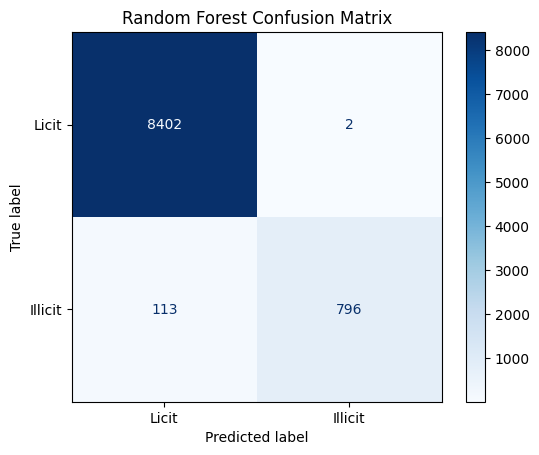

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Licit", "Illicit"])

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

In [10]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 8402
False Positives: 2
False Negatives: 113
True Positives: 796


In [11]:
baseline_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1 Score": [rf_f1],
    "PR-AUC": [rf_pr_auc],
    "False Negatives": [fn]
})

baseline_results

,Model,Precision,Recall,F1 Score,PR-AUC,False Negatives
0,Random Forest,0.997494,0.875688,0.93263,0.980001,113


In [12]:
results_path = PROJECT_ROOT / "results" / "tables" / "baseline_results.csv"

baseline_results.to_csv(results_path, index=False)

print("Results saved to:", results_path)

Results saved to: ..\results\tables\baseline_results.csv


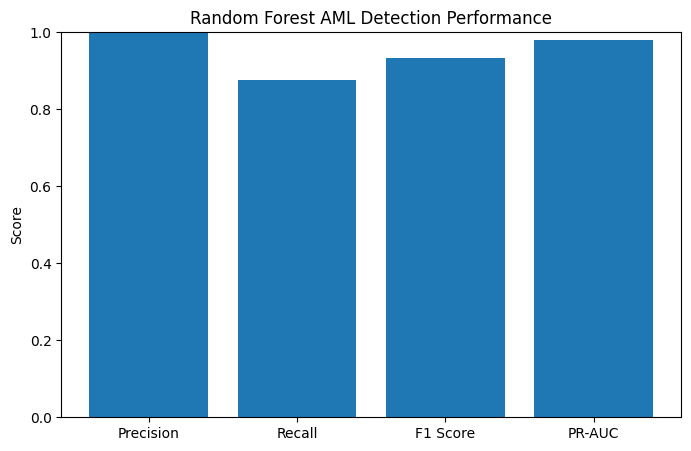

In [13]:
metrics = ["Precision", "Recall", "F1 Score", "PR-AUC"]
values = [rf_precision, rf_recall, rf_f1, rf_pr_auc]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)

plt.ylim(0,1)
plt.title("Random Forest AML Detection Performance")
plt.ylabel("Score")

plt.show()

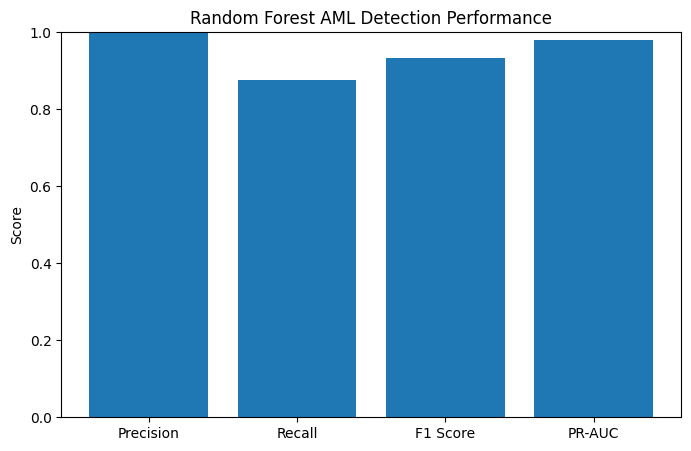

Figure saved to: ..\results\figures\baseline_rf_metrics.png


In [14]:
fig_path = PROJECT_ROOT / "results" / "figures" / "baseline_rf_metrics.png"

plt.figure(figsize=(8,5))
plt.bar(metrics, values)

plt.ylim(0,1)
plt.title("Random Forest AML Detection Performance")
plt.ylabel("Score")

plt.savefig(fig_path)

plt.show()

print("Figure saved to:", fig_path)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, f1_score, average_precision_score, classification_report

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/processed/elliptic_clean.csv")
df.head()

,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166,label
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,0
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,0


In [3]:
print(df.columns.tolist())
print(df.shape)

['txId', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'feature_69', 'feature_70', 'feature_71', 'featu

In [4]:
df.columns

Index(['txId', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'feature_9',
       ...
       'feature_158', 'feature_159', 'feature_160', 'feature_161',
       'feature_162', 'feature_163', 'feature_164', 'feature_165',
       'feature_166', 'label'],
      dtype='str', length=168)

In [6]:
print(df.columns.tolist())

['txId', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'feature_69', 'feature_70', 'feature_71', 'featu

In [7]:
df.head()

,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166,label
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,0
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,0


In [8]:
target_col = "class"

In [10]:
print(df.columns.tolist())

['txId', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'feature_69', 'feature_70', 'feature_71', 'featu

In [11]:
df.head()

,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166,label
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,0
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46564 entries, 0 to 46563
Columns: 168 entries, txId to label
dtypes: float64(165), int64(3)
memory usage: 59.7 MB


In [13]:
target_col = "label"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (46564, 167)
y shape: (46564,)
label
0    42019
1     4545
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (37251, 167)
X_test shape: (9313, 167)
y_train shape: (37251,)
y_test shape: (9313,)


In [15]:
target_col = "label"

X = df.drop(columns=[target_col, "txId"])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (46564, 166)
y shape: (46564,)
label
0    42019
1     4545
Name: count, dtype: int64


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, average_precision_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print("Random Forest Results")
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("PR-AUC:", rf_pr_auc)
print(classification_report(y_test, rf_pred))

Random Forest Results
Recall: 0.9130913091309131
F1 Score: 0.9346846846846847
PR-AUC: 0.975410979480224
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8404
           1       0.96      0.91      0.93       909

    accuracy                           0.99      9313
   macro avg       0.97      0.95      0.96      9313
weighted avg       0.99      0.99      0.99      9313



In [17]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, f1_score, average_precision_score, classification_report

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)
ada_prob = ada_model.predict_proba(X_test)[:, 1]

ada_recall = recall_score(y_test, ada_pred)
ada_f1 = f1_score(y_test, ada_pred)
ada_pr_auc = average_precision_score(y_test, ada_prob)

print("AdaBoost Results")
print("Recall:", ada_recall)
print("F1 Score:", ada_f1)
print("PR-AUC:", ada_pr_auc)
print(classification_report(y_test, ada_pred))

AdaBoost Results
Recall: 0.6347634763476347
F1 Score: 0.7459599224305107
PR-AUC: 0.8386823606097975
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      8404
           1       0.90      0.63      0.75       909

    accuracy                           0.96      9313
   macro avg       0.93      0.81      0.86      9313
weighted avg       0.96      0.96      0.95      9313



In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score, average_precision_score, classification_report

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)

print("XGBoost Results")
print("Recall:", xgb_recall)
print("F1 Score:", xgb_f1)
print("PR-AUC:", xgb_pr_auc)
print(classification_report(y_test, xgb_pred))

XGBoost Results
Recall: 0.9515951595159516
F1 Score: 0.9402173913043478
PR-AUC: 0.9849362779516793
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8404
           1       0.93      0.95      0.94       909

    accuracy                           0.99      9313
   macro avg       0.96      0.97      0.97      9313
weighted avg       0.99      0.99      0.99      9313



In [19]:
results = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost", "XGBoost"],
    "Recall": [rf_recall, ada_recall, xgb_recall],
    "F1 Score": [rf_f1, ada_f1, xgb_f1],
    "PR-AUC": [rf_pr_auc, ada_pr_auc, xgb_pr_auc]
})

results

,Model,Recall,F1 Score,PR-AUC
0,Random Forest,0.913091,0.934685,0.975411
1,AdaBoost,0.634763,0.745960,0.838682
2,XGBoost,0.951595,0.940217,0.984936


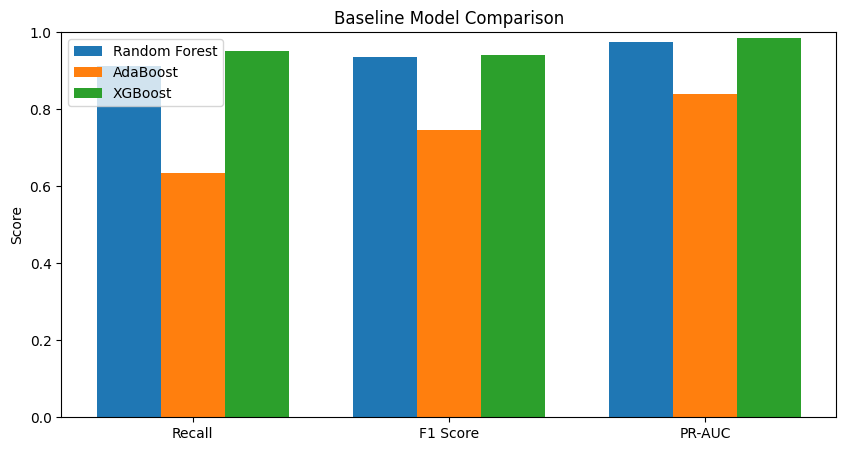

In [20]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Recall", "F1 Score", "PR-AUC"]

rf_vals = [rf_recall, rf_f1, rf_pr_auc]
ada_vals = [ada_recall, ada_f1, ada_pr_auc]
xgb_vals = [xgb_recall, xgb_f1, xgb_pr_auc]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, rf_vals, width, label="Random Forest")
plt.bar(x, ada_vals, width, label="AdaBoost")
plt.bar(x + width, xgb_vals, width, label="XGBoost")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline Model Comparison")
plt.legend()
plt.show()

In [21]:
results.to_csv("../results/tables/baseline_model_comparison.csv", index=False)


In [23]:
from sklearn.metrics import precision_score, confusion_matrix

# Precision
rf_precision = precision_score(y_test, rf_pred)
ada_precision = precision_score(y_test, ada_pred)
xgb_precision = precision_score(y_test, xgb_pred)

# Confusion matrix counts
rf_cm = confusion_matrix(y_test, rf_pred)
ada_cm = confusion_matrix(y_test, ada_pred)
xgb_cm = confusion_matrix(y_test, xgb_pred)

rf_fp, rf_fn = rf_cm[0, 1], rf_cm[1, 0]
ada_fp, ada_fn = ada_cm[0, 1], ada_cm[1, 0]
xgb_fp, xgb_fn = xgb_cm[0, 1], xgb_cm[1, 0]

baseline_results = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost", "XGBoost"],
    "Precision": [rf_precision, ada_precision, xgb_precision],
    "Recall": [rf_recall, ada_recall, xgb_recall],
    "F1 Score": [rf_f1, ada_f1, xgb_f1],
    "PR-AUC": [rf_pr_auc, ada_pr_auc, xgb_pr_auc],
    "False Positives": [rf_fp, ada_fp, xgb_fp],
    "False Negatives": [rf_fn, ada_fn, xgb_fn]
})

baseline_results

,Model,Precision,Recall,F1 Score,PR-AUC,False Positives,False Negatives
0,Random Forest,0.957324,0.913091,0.934685,0.975411,37,79
1,AdaBoost,0.904389,0.634763,0.745960,0.838682,61,332
2,XGBoost,0.929108,0.951595,0.940217,0.984936,66,44


In [24]:
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [25]:
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)
ada_prob = ada_model.predict_proba(X_test)[:, 1]

In [26]:
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [27]:
from sklearn.metrics import precision_score, confusion_matrix
import pandas as pd

rf_precision = precision_score(y_test, rf_pred)
ada_precision = precision_score(y_test, ada_pred)
xgb_precision = precision_score(y_test, xgb_pred)

rf_cm = confusion_matrix(y_test, rf_pred)
ada_cm = confusion_matrix(y_test, ada_pred)
xgb_cm = confusion_matrix(y_test, xgb_pred)

rf_fp, rf_fn = rf_cm[0, 1], rf_cm[1, 0]
ada_fp, ada_fn = ada_cm[0, 1], ada_cm[1, 0]
xgb_fp, xgb_fn = xgb_cm[0, 1], xgb_cm[1, 0]

baseline_results = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost", "XGBoost"],
    "Precision": [rf_precision, ada_precision, xgb_precision],
    "Recall": [rf_recall, ada_recall, xgb_recall],
    "F1 Score": [rf_f1, ada_f1, xgb_f1],
    "PR-AUC": [rf_pr_auc, ada_pr_auc, xgb_pr_auc],
    "False Positives": [rf_fp, ada_fp, xgb_fp],
    "False Negatives": [rf_fn, ada_fn, xgb_fn]
})

baseline_results

,Model,Precision,Recall,F1 Score,PR-AUC,False Positives,False Negatives
0,Random Forest,0.957324,0.913091,0.934685,0.975411,37,79
1,AdaBoost,0.904389,0.634763,0.745960,0.838682,61,332
2,XGBoost,0.929108,0.951595,0.940217,0.984936,66,44


In [28]:
baseline_results.to_csv("../results/tables/baseline_results.csv", index=False)